In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from glob import glob
from scipy import stats
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Mid-infrared (MIR) spectroscopy: finding the optimal tissue thickness

Optimalization function: $$Q(t:\text{thickness}) = D_{\text{baseline}}(t) + D_{\text{saturation}}(t)$$
Here:
- $D_{\text{baseline}}(t)$ baseline distortion (non-linearity, deformation) compared to a fitted line in the empty spectral region (normalized)
- $D_{\text{saturation}}(t)$ fraction of saturated spectra within a thickness group defined by the Amide I/II peak ratios (normalized)
- Optimal thickness is where $Q$ is minimal.

Explanation:
- The baseline curvature (or deformation) penalty is computed in the following way. We took the biologically empty spectral region 2700 - 1800 1/cm and excluded from it the CO$_2$ peak (2390-2280 1/cm). Then, we applied linear regression to the remaining area, since it should have a shape close to a line. Then, we computed the RMSE of the fit as the baseline penalty for every spectrum. The mean value per thickness is the quality metric.
- The saturation penalty is the normalized fraction of spectra per thickness that were flagged as saturated. The article (https://acta-arhiv.chem-soc.si/50/50-4-777.pdf) which states that “So-called saturation effects take place and disturb the band shape of the Amide bands. In cast or self-standing films the ratio between the Amide I and Amide II band should be higher than 1.1 and this can be achieved only for protein films thinner than 4 μm. Only when this condition is fulfilled can the Amide I band be safely used for structural investigation.” (Although this is transmission-based.) We computed the peak ratio of the Amide I and II bands, and if the value of a spectrum was below that, then that spectrum was flagged as saturated. The quality metric is the fraction of saturated spectra per thickness normalized.

## Loading data, conversion to absorbance, filtering background

In [2]:
# Available thickness values combined with file order
ths = [12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 16, 16, 2, 2, 2, 2, 2, 2, 8, 8, 8, 8, 8, 8]

# Get the list of all relevant files
path = "/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra"
dir_list = sorted(glob(f'{path}/CStmacrc*'))
print(*dir_list, sep="\n")

/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_12mic_A1_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_12mic_A2_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_12mic_B3_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_12mic_C2_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_12mic_C3_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_12mic_D2_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_16mic_A1_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_16mic_A2_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_16mic_B3_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR_MS/MIR_new_data/spectra/CStmacrc_16mic_C2_res8_co16_2.2int_50.txt
/home/borbende/wsi/csongor_MIR

In [3]:
# Adding some metadata (only core IDs are truly needed here)

labels = []
colon = []

ncs = ['B3', 'D2']
crcs = ['A1', 'C2']
crlms = ['A2', 'C3']


for i in dir_list:
    lab = i[-26:-24]    # Core id: "B1"
    labels.append(lab)
    if lab in ncs:
        colon.append('NC')
    elif lab in crcs:
        colon.append('CRC')
    else:
        colon.append('CRLM')

In [4]:
%%time
# Combining everything

dfs = []
for i in range(len(dir_list)):
    frame = pd.read_csv(dir_list[i], index_col = 0)
    frame['labels'] = labels[i]
    frame['colon'] = colon[i]
    frame['thickness'] = ths[i]
    dfs.append(frame)
    
df = pd.concat(dfs, axis=0, ignore_index=True)
print(df.shape)
df.head(10)

(46464, 819)
CPU times: user 1.7 s, sys: 209 ms, total: 1.91 s
Wall time: 1.91 s


,X,Y,4000.0,3996.0,3992.0,3988.0,3984.0,3980.0,3976.0,3972.0,...,772.0,768.0,764.0,760.0,756.0,752.0,748.0,labels,colon,thickness
0,-1074.999957,1074.999957,88.751510,88.866585,88.704990,88.531395,88.611946,88.820420,88.963110,88.835800,...,88.177025,88.19417,88.18522,88.167720,88.25104,88.362206,88.388560,A1,CRC,12
1,-1024.999959,1074.999957,83.406500,83.446400,83.370130,83.257860,83.267230,83.348700,83.427630,83.410910,...,84.682144,84.72193,84.76389,84.734940,84.77264,84.915670,84.991660,A1,CRC,12
2,-974.999961,1074.999957,86.729290,86.868990,86.814865,86.748090,86.749565,86.851210,86.969830,86.945114,...,85.795900,85.86078,85.97002,86.033936,86.08711,86.148330,86.223465,A1,CRC,12
3,-924.999963,1074.999957,85.454040,85.528950,85.493520,85.331375,85.244360,85.328995,85.449875,85.413930,...,85.177770,85.25265,85.35329,85.393555,85.37140,85.396630,85.465300,A1,CRC,12
4,-874.999965,1074.999957,88.536705,88.610090,88.560150,88.374310,88.275750,88.424065,88.548676,88.444000,...,87.662710,87.69819,87.74785,87.818060,87.91302,87.959550,87.955986,A1,CRC,12
5,-824.999967,1074.999957,85.516300,85.512276,85.477190,85.468370,85.484340,85.474174,85.572586,85.573840,...,86.926020,86.96435,86.92989,86.902664,86.94372,87.019290,87.151596,A1,CRC,12
6,-774.999969,1074.999957,87.773770,87.809070,87.706505,87.632065,87.603970,87.736940,87.924830,87.877396,...,88.206090,88.19418,88.23104,88.269510,88.31163,88.358690,88.426660,A1,CRC,12
7,-724.999971,1074.999957,84.916435,85.136154,85.171390,84.995760,84.804720,84.883440,85.118640,85.125440,...,85.184050,85.21805,85.24696,85.330400,85.42822,85.508705,85.535420,A1,CRC,12
8,-674.999973,1074.999957,85.456190,85.548065,85.484825,85.373830,85.183266,85.147110,85.283350,85.345840,...,84.579560,84.52144,84.45928,84.524360,84.63983,84.644930,84.601425,A1,CRC,12
9,-624.999975,1074.999957,83.344890,83.438220,83.424130,83.332570,83.316200,83.405260,83.452324,83.344430,...,84.344536,84.35850,84.38411,84.331850,84.25664,84.257830,84.345510,A1,CRC,12


In [5]:
# Removing faulty data
df = df[(df['labels'] != 'C2') | (df['thickness'] != 12)].reset_index(drop = True)

In [6]:
# Sanity check
df[(df['labels'] == 'C2') & (df['thickness'] == 12)]

,X,Y,4000.0,3996.0,3992.0,3988.0,3984.0,3980.0,3976.0,3972.0,...,772.0,768.0,764.0,760.0,756.0,752.0,748.0,labels,colon,thickness


In [7]:
df.isna().sum().sum(), df.isnull().sum().sum()

(0, 0)

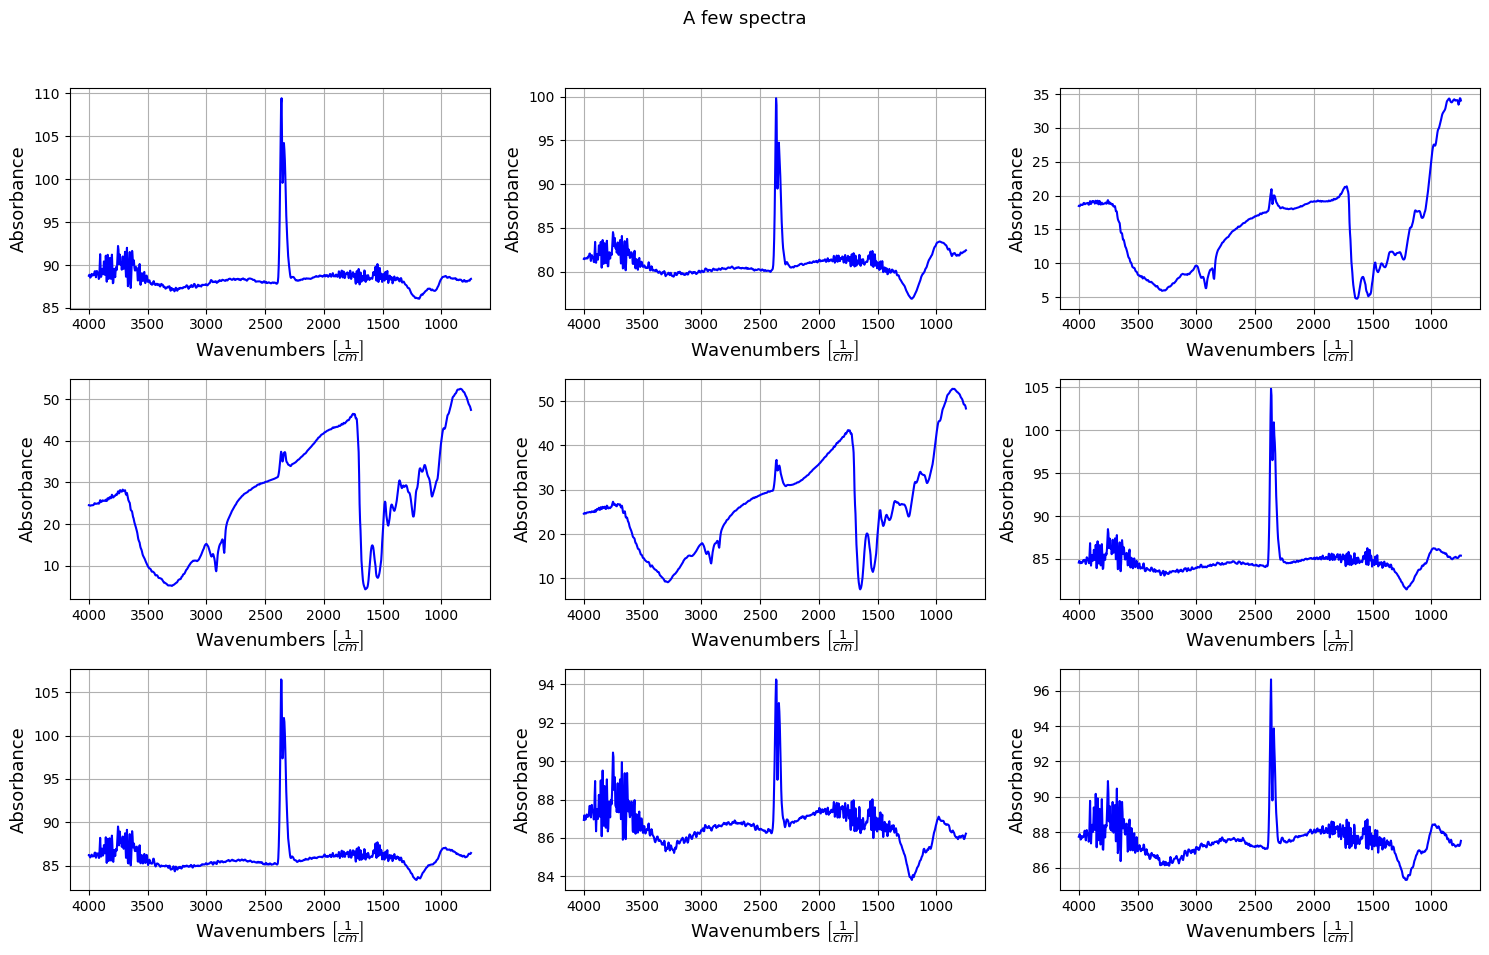

In [8]:
plt.figure(figsize = (15, 10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(df.columns.values[2:-3].astype(np.float64), df.iloc[i * 300,2:-3], color = "b")
    plt.xlabel(r"Wavenumbers $\left[\frac{1}{cm}\right]$", fontsize = 13)
    plt.ylabel("Absorbance", fontsize = 13)
    plt.grid()
    plt.gca().invert_xaxis()
    
plt.suptitle("A few spectra", fontsize = 13)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
df2 = df.copy()
df2

,X,Y,4000.0,3996.0,3992.0,3988.0,3984.0,3980.0,3976.0,3972.0,...,772.0,768.0,764.0,760.0,756.0,752.0,748.0,labels,colon,thickness
0,-1074.999957,1074.999957,88.751510,88.866585,88.704990,88.531395,88.611946,88.820420,88.963110,88.835800,...,88.177025,88.194170,88.185220,88.167720,88.251040,88.362206,88.388560,A1,CRC,12
1,-1024.999959,1074.999957,83.406500,83.446400,83.370130,83.257860,83.267230,83.348700,83.427630,83.410910,...,84.682144,84.721930,84.763890,84.734940,84.772640,84.915670,84.991660,A1,CRC,12
2,-974.999961,1074.999957,86.729290,86.868990,86.814865,86.748090,86.749565,86.851210,86.969830,86.945114,...,85.795900,85.860780,85.970020,86.033936,86.087110,86.148330,86.223465,A1,CRC,12
3,-924.999963,1074.999957,85.454040,85.528950,85.493520,85.331375,85.244360,85.328995,85.449875,85.413930,...,85.177770,85.252650,85.353290,85.393555,85.371400,85.396630,85.465300,A1,CRC,12
4,-874.999965,1074.999957,88.536705,88.610090,88.560150,88.374310,88.275750,88.424065,88.548676,88.444000,...,87.662710,87.698190,87.747850,87.818060,87.913020,87.959550,87.955986,A1,CRC,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44523,874.999965,-1074.999957,93.181710,93.158980,93.047264,93.026150,93.126720,93.389220,93.454180,93.198740,...,91.715910,91.815570,91.886240,91.816666,91.691840,91.586150,91.577515,D2,NC,8
44524,924.999963,-1074.999957,84.348200,84.360600,84.248840,83.979400,83.812485,84.050890,84.331610,84.247690,...,87.470375,87.513850,87.527860,87.441120,87.354470,87.416565,87.490610,D2,NC,8
44525,974.999961,-1074.999957,93.311420,93.376690,93.232540,93.011100,93.006570,93.209496,93.404760,93.368835,...,92.177390,92.186300,92.248760,92.292465,92.213646,92.119484,92.136950,D2,NC,8
44526,1024.999959,-1074.999957,92.246210,92.187340,92.028400,91.983310,92.118270,92.156000,92.000565,91.880350,...,92.056920,92.033195,91.947914,91.901780,91.942410,91.956400,91.843870,D2,NC,8


In [10]:
specnum = 1936  # Number of spectra in one such file (all have the same pixel resolution)
print(specnum)
print(labels)
print(len(labels))  # Number of files

1936
['A1', 'A2', 'B3', 'C2', 'C3', 'D2', 'A1', 'A2', 'B3', 'C2', 'C3', 'D2', 'A1', 'A2', 'B3', 'C2', 'C3', 'D2', 'A1', 'A2', 'B3', 'C2', 'C3', 'D2']
24


In [11]:
%%time
# Filtering out slide background spectra

df2["avg"] = df2.iloc[:,2:-3].mean(axis = 1)   # Average absorbance to help Kmeans clustering
df2["kmeans"] = 0
for i in range(len(labels) - 1):
    kmeans = KMeans(n_clusters = 2, n_init='auto')
    trafo = kmeans.fit_transform(df2.iloc[i*specnum:(i+1)*specnum,2:-5])
    ind = df2[i*specnum:(i+1)*specnum][df2[i*specnum:(i+1)*specnum]["avg"] == min(df2[i*specnum:(i+1)*specnum]["avg"])].index[0]
    ind2 = ind - (i * specnum)
    if kmeans.labels_[ind2] == 0:
        df2.iloc[i*specnum:(i+1)*specnum,-1] = kmeans.labels_
    else:
        df2.iloc[i*specnum:(i+1)*specnum,-1] = 1 - kmeans.labels_

CPU times: user 23.6 s, sys: 36.3 s, total: 59.9 s
Wall time: 3.23 s


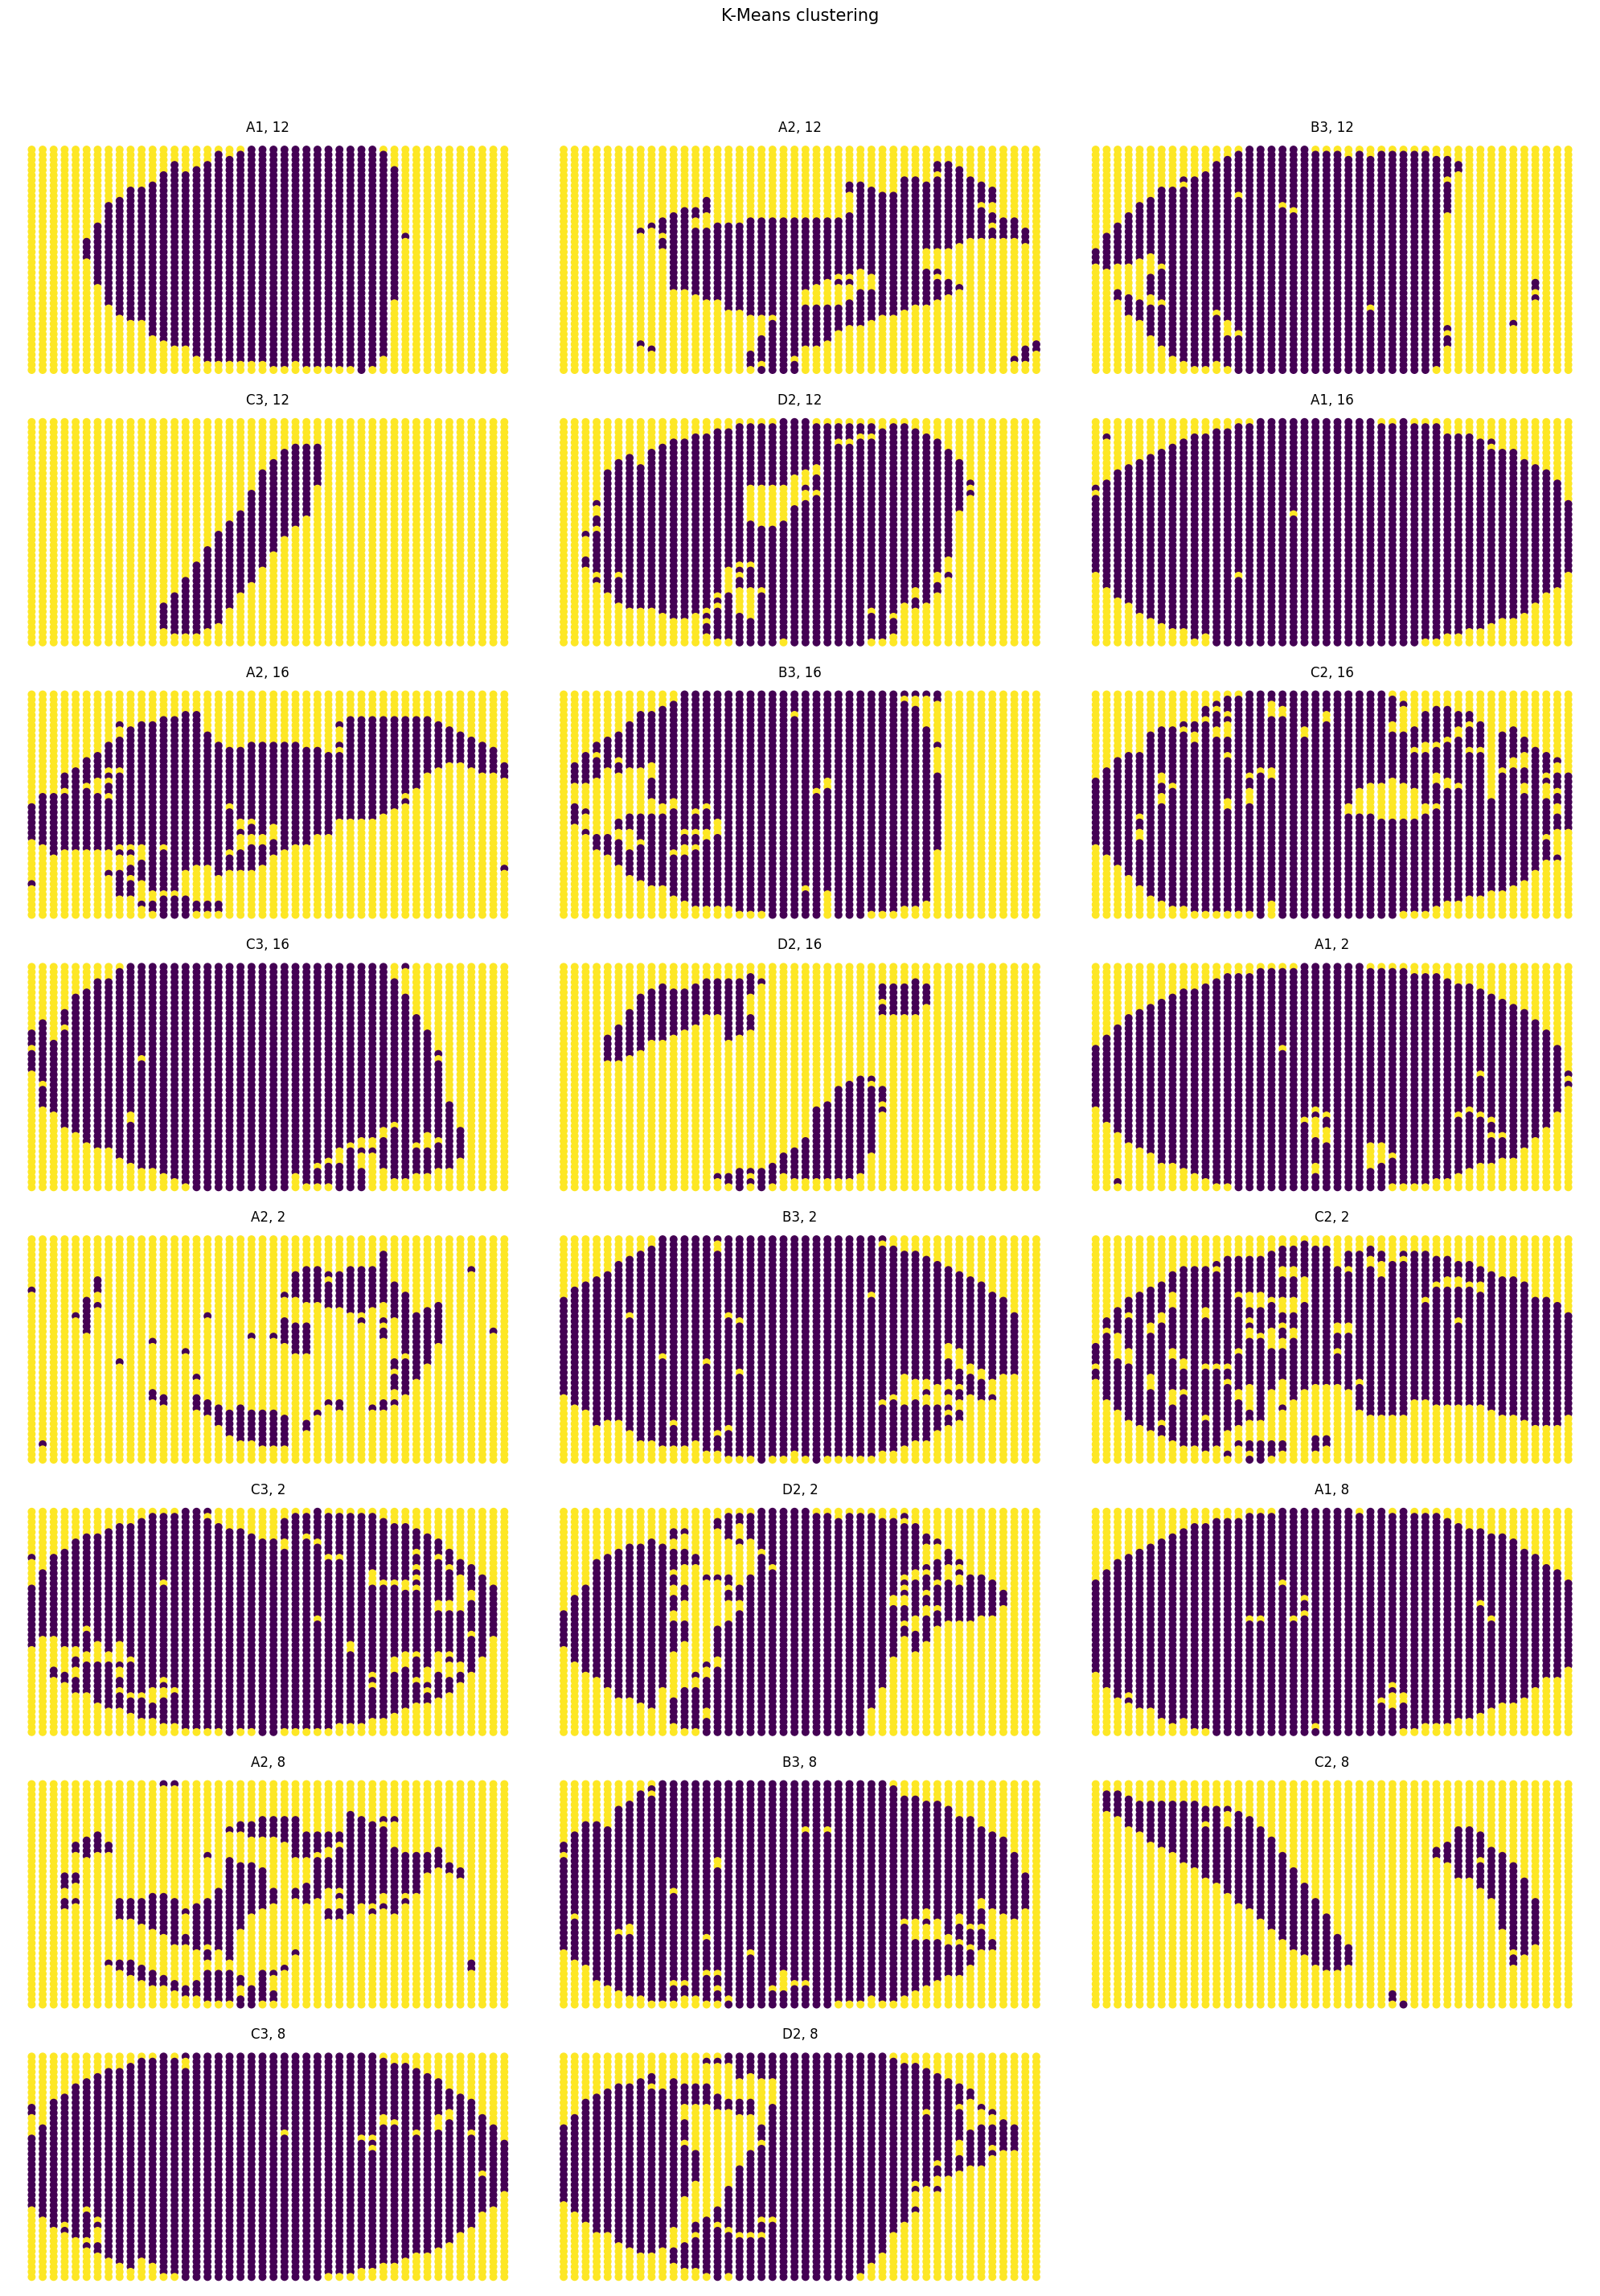

In [12]:
# Tissue and background spectra overlay

plt.figure(figsize = (20, 30))

for i in range(len(labels) - 1):
    plt.subplot(8, 3, i + 1)
    plt.scatter(df2.iloc[i*specnum:(i+1)*specnum,0], df2.iloc[i*specnum:(i+1)*specnum,1], 
                c = df2.iloc[i*specnum:(i+1)*specnum, -1], marker = ".", s = 150, alpha = 1.0)
    plt.axis('off')
    plt.title(f"{df2.iloc[i*specnum:(i+1)*specnum,-5].iloc[0]}, {df2.iloc[i*specnum:(i+1)*specnum,-3].iloc[0]}")

plt.suptitle("K-Means clustering", fontsize = 15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [13]:
bg_df = df2[df2["kmeans"] == 1]  # Background spectra (if needed)
bg_df = bg_df.drop(['avg', 'kmeans'], axis = 1)
bg_df

,X,Y,4000.0,3996.0,3992.0,3988.0,3984.0,3980.0,3976.0,3972.0,...,772.0,768.0,764.0,760.0,756.0,752.0,748.0,labels,colon,thickness
0,-1074.999957,1074.999957,88.751510,88.866585,88.704990,88.531395,88.611946,88.820420,88.963110,88.835800,...,88.177025,88.194170,88.185220,88.167720,88.251040,88.362206,88.388560,A1,CRC,12
1,-1024.999959,1074.999957,83.406500,83.446400,83.370130,83.257860,83.267230,83.348700,83.427630,83.410910,...,84.682144,84.721930,84.763890,84.734940,84.772640,84.915670,84.991660,A1,CRC,12
2,-974.999961,1074.999957,86.729290,86.868990,86.814865,86.748090,86.749565,86.851210,86.969830,86.945114,...,85.795900,85.860780,85.970020,86.033936,86.087110,86.148330,86.223465,A1,CRC,12
3,-924.999963,1074.999957,85.454040,85.528950,85.493520,85.331375,85.244360,85.328995,85.449875,85.413930,...,85.177770,85.252650,85.353290,85.393555,85.371400,85.396630,85.465300,A1,CRC,12
4,-874.999965,1074.999957,88.536705,88.610090,88.560150,88.374310,88.275750,88.424065,88.548676,88.444000,...,87.662710,87.698190,87.747850,87.818060,87.913020,87.959550,87.955986,A1,CRC,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44523,874.999965,-1074.999957,93.181710,93.158980,93.047264,93.026150,93.126720,93.389220,93.454180,93.198740,...,91.715910,91.815570,91.886240,91.816666,91.691840,91.586150,91.577515,D2,NC,8
44524,924.999963,-1074.999957,84.348200,84.360600,84.248840,83.979400,83.812485,84.050890,84.331610,84.247690,...,87.470375,87.513850,87.527860,87.441120,87.354470,87.416565,87.490610,D2,NC,8
44525,974.999961,-1074.999957,93.311420,93.376690,93.232540,93.011100,93.006570,93.209496,93.404760,93.368835,...,92.177390,92.186300,92.248760,92.292465,92.213646,92.119484,92.136950,D2,NC,8
44526,1024.999959,-1074.999957,92.246210,92.187340,92.028400,91.983310,92.118270,92.156000,92.000565,91.880350,...,92.056920,92.033195,91.947914,91.901780,91.942410,91.956400,91.843870,D2,NC,8


In [14]:
df2 = df2[df2["kmeans"] == 0]   # Tissue spectra
df2 = df2.drop(['avg', 'kmeans'], axis = 1)
df2

,X,Y,4000.0,3996.0,3992.0,3988.0,3984.0,3980.0,3976.0,3972.0,...,772.0,768.0,764.0,760.0,756.0,752.0,748.0,labels,colon,thickness
20,-74.999997,1074.999957,44.007290,44.130165,44.101930,44.001072,43.975170,44.063570,44.148956,44.079950,...,48.591473,48.441982,48.420570,48.418865,48.409880,48.412746,48.364967,A1,CRC,12
21,-24.999999,1074.999957,30.070894,30.198915,30.219925,30.146791,30.068945,29.993547,29.999437,30.114902,...,50.259094,49.860497,49.709230,49.587597,49.336464,49.020990,48.659590,A1,CRC,12
22,24.999999,1074.999957,29.543371,29.664963,29.770554,29.729174,29.559319,29.502827,29.618595,29.691840,...,53.994580,53.601845,53.338720,53.104256,52.769703,52.381750,51.977510,A1,CRC,12
23,74.999997,1074.999957,23.413000,23.467810,23.438430,23.357712,23.347769,23.474243,23.599878,23.575932,...,51.000847,50.742410,50.605180,50.503242,50.300056,50.024975,49.728550,A1,CRC,12
24,124.999995,1074.999957,37.561855,37.471350,37.369602,37.336094,37.398468,37.532520,37.587170,37.569675,...,54.248688,54.149254,54.121360,54.148070,54.118233,54.040394,53.932680,A1,CRC,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44506,24.999999,-1074.999957,33.416145,33.424744,33.262074,33.118214,33.114280,33.178390,33.112385,32.983315,...,54.150063,54.049458,53.812310,53.532950,53.217453,52.771908,52.319504,D2,NC,8
44507,74.999997,-1074.999957,29.937868,29.944311,29.862696,29.746752,29.694270,29.725971,29.887537,30.043550,...,53.278465,53.089806,52.811905,52.467500,52.057415,51.526596,50.996784,D2,NC,8
44508,124.999995,-1074.999957,26.782051,26.705850,26.559114,26.454870,26.607191,26.885090,26.902988,26.744915,...,60.487810,60.224194,59.959435,59.664280,59.225193,58.734695,58.321365,D2,NC,8
44509,174.999993,-1074.999957,24.585852,24.741005,24.773888,24.634516,24.498940,24.570032,24.653801,24.571077,...,66.145134,65.980830,65.732770,65.407135,65.063370,64.708430,64.386100,D2,NC,8


In [15]:
def tr2ab(data):                               # From transmittance % to absorbance.
    return -np.log10(data / 100)

df2.iloc[:, 2:-3] = tr2ab(df2.iloc[:, 2:-3])

In [16]:
df2

,X,Y,4000.0,3996.0,3992.0,3988.0,3984.0,3980.0,3976.0,3972.0,...,772.0,768.0,764.0,760.0,756.0,752.0,748.0,labels,colon,thickness
20,-74.999997,1074.999957,0.356475,0.355264,0.355542,0.356537,0.356792,0.355920,0.355080,0.355759,...,0.313440,0.314778,0.314970,0.314985,0.315066,0.315040,0.315469,A1,CRC,12
21,-24.999999,1074.999957,0.521854,0.520009,0.519707,0.520759,0.521882,0.522972,0.522887,0.521219,...,0.298785,0.302243,0.303563,0.304627,0.306832,0.309618,0.312832,A1,CRC,12
22,24.999999,1074.999957,0.529540,0.527756,0.526213,0.526817,0.529306,0.530136,0.528436,0.527363,...,0.267650,0.270820,0.272957,0.274871,0.277615,0.280820,0.284185,A1,CRC,12
23,74.999997,1074.999957,0.630543,0.629527,0.630071,0.631570,0.631755,0.629408,0.627090,0.627531,...,0.292423,0.294629,0.295805,0.296681,0.298432,0.300813,0.303394,A1,CRC,12
24,124.999995,1074.999957,0.425253,0.426301,0.427482,0.427871,0.427146,0.425592,0.424960,0.425163,...,0.265611,0.266408,0.266631,0.266417,0.266656,0.267281,0.268148,A1,CRC,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44506,24.999999,-1074.999957,0.476044,0.475932,0.478051,0.479933,0.479985,0.479145,0.480010,0.481706,...,0.266401,0.267209,0.269118,0.271379,0.273946,0.277597,0.281336,D2,NC,8
44507,74.999997,-1074.999957,0.523779,0.523686,0.524871,0.526560,0.527327,0.526864,0.524510,0.522249,...,0.273448,0.274989,0.277268,0.280110,0.283517,0.287969,0.292457,D2,NC,8
44508,124.999995,-1074.999957,0.572156,0.573394,0.575786,0.577494,0.575001,0.570489,0.570199,0.572759,...,0.218332,0.220229,0.222142,0.224286,0.227494,0.231105,0.234172,D2,NC,8
44509,174.999993,-1074.999957,0.609315,0.606583,0.606006,0.608456,0.610853,0.609594,0.608116,0.609576,...,0.179502,0.180582,0.182218,0.184375,0.186663,0.189039,0.191208,D2,NC,8


## Thickness optimalization

In [17]:
from sklearn.preprocessing import MinMaxScaler
from scipy.integrate import trapezoid
from scipy.stats import linregress

In [18]:
df = df2.copy().reset_index(drop = True)

In [19]:
meta_cols = ["X", "Y", "labels", "colon", "thickness"]  # Non-spectral columns

spectral_cols = [
    c for c in df.columns
    if c not in meta_cols
]

wn = np.array([float(c) for c in spectral_cols]) # Converts spectral column names to float wavenumbers
sort_idx = np.argsort(wn) # Sort from low to high
wn_sorted = wn[sort_idx]
spectral_cols_sorted = [spectral_cols[i] for i in sort_idx]

Xspec = df[spectral_cols_sorted].to_numpy(dtype=float) # All spectral data

In [20]:
def band_mask(wn, low, high):  # To examine certain regions
    return (wn >= low) & (wn <= high)

def max_band_absorbance(spectra, wn, low, high):  # The absorbance at a peak
    mask = band_mask(wn, low, high)
    return np.nanmax(spectra[:, mask], axis=1)


def baseline_curvature_penalty(spectra, wn, low=1800, high=2700, exclude=(2280, 2390)):
    mask = band_mask(wn, low, high)  # Certain region (baseline)
    if exclude is not None:    # Remove a smaller region within the mask (CO2)
        ex_low, ex_high = exclude
        mask &= ~band_mask(wn, ex_low, ex_high)

    x = wn[mask]
    Y = spectra[:, mask]

    penalties = []

    for y in Y:
        # Fitting a line to the baseline
        p = np.polyfit(x, y, deg=1)
        y_fit = np.polyval(p, x)

        # RMS residual = baseline deformation or curvature estimate
        rms = np.sqrt(np.mean((y - y_fit) ** 2))
        penalties.append(rms)

    return np.array(penalties)

In [21]:
metrics = df[["X", "Y", "labels", "colon", "thickness"]].copy()

# Strong-band maximum: amide I, II
metrics["amide_I_max"] = max_band_absorbance(Xspec, wn_sorted, 1600, 1700)
metrics["amide_II_max"] = max_band_absorbance(Xspec, wn_sorted, 1500, 1580)

# Amide I/II peak ratio
metrics["amide_I_II_ratio"] = metrics["amide_I_max"] / metrics["amide_II_max"]

# Baseline penalty
metrics["baseline_penalty"] = baseline_curvature_penalty(
    Xspec,
    wn_sorted,
    low=1800,
    high=2700,
    exclude=(2280, 2390)
)

In [22]:
metrics

,X,Y,labels,colon,thickness,amide_I_max,amide_II_max,amide_I_II_ratio,baseline_penalty
0,-74.999997,1074.999957,A1,CRC,12,0.483987,0.478245,1.012007,0.002000
1,-24.999999,1074.999957,A1,CRC,12,0.872952,0.798675,1.093000,0.004296
2,24.999999,1074.999957,A1,CRC,12,0.844576,0.774217,1.090877,0.008172
3,74.999997,1074.999957,A1,CRC,12,0.870255,0.831949,1.046044,0.008678
4,124.999995,1074.999957,A1,CRC,12,0.523148,0.509780,1.026225,0.005277
...,...,...,...,...,...,...,...,...,...
24212,24.999999,-1074.999957,D2,NC,8,0.969981,0.813109,1.192928,0.004029
24213,74.999997,-1074.999957,D2,NC,8,1.137538,1.006487,1.130206,0.013828
24214,124.999995,-1074.999957,D2,NC,8,0.827286,0.730551,1.132414,0.004298
24215,174.999993,-1074.999957,D2,NC,8,0.885705,0.809633,1.093959,0.013237


In [23]:
summary = (
    metrics
    .groupby("thickness")
    .agg(
        n=("thickness", "size"),
        baseline_penalty_mean=("baseline_penalty", "mean"),
        baseline_penalty_std=("baseline_penalty", "std"),
        amide_I_max_mean=("amide_I_max", "mean"),
        amide_I_max_std=("amide_I_max", "std"),
        amide_II_max_mean=("amide_II_max", "mean"),
        amide_I_II_ratio_mean=("amide_I_II_ratio", "mean"),
        amide_I_II_ratio_std=("amide_I_II_ratio", "std"),
    )
    .reset_index()
    .sort_values("thickness")
)

In [24]:
summary

,thickness,n,baseline_penalty_mean,baseline_penalty_std,amide_I_max_mean,amide_I_max_std,amide_II_max_mean,amide_I_II_ratio_mean,amide_I_II_ratio_std
0,2,6755,0.005351,0.004273,0.550547,0.180792,0.437621,1.252489,0.106651
1,8,6616,0.008783,0.004913,0.895021,0.319037,0.774448,1.160501,0.113895
2,12,4158,0.009424,0.004656,1.218001,0.414034,1.126964,1.075302,0.066622
3,16,6688,0.009606,0.005087,1.209197,0.420781,1.100067,1.093532,0.095254


In [25]:
# Saturation penalty
# Literature-inspired saturation flag
metrics["is_saturated"] = metrics["amide_I_II_ratio"] <= 1.1

sat_summary = (
    metrics
    .groupby("thickness")["is_saturated"]
    .mean()
    .reset_index()
    .rename(columns={"is_saturated": "saturation_fraction"})
)

summary = summary.merge(sat_summary, on="thickness", how="left")
summary

,thickness,n,baseline_penalty_mean,baseline_penalty_std,amide_I_max_mean,amide_I_max_std,amide_II_max_mean,amide_I_II_ratio_mean,amide_I_II_ratio_std,saturation_fraction
0,2,6755,0.005351,0.004273,0.550547,0.180792,0.437621,1.252489,0.106651,0.067061
1,8,6616,0.008783,0.004913,0.895021,0.319037,0.774448,1.160501,0.113895,0.354293
2,12,4158,0.009424,0.004656,1.218001,0.414034,1.126964,1.075302,0.066622,0.699615
3,16,6688,0.009606,0.005087,1.209197,0.420781,1.100067,1.093532,0.095254,0.645783


In [26]:
metrics

,X,Y,labels,colon,thickness,amide_I_max,amide_II_max,amide_I_II_ratio,baseline_penalty,is_saturated
0,-74.999997,1074.999957,A1,CRC,12,0.483987,0.478245,1.012007,0.002000,True
1,-24.999999,1074.999957,A1,CRC,12,0.872952,0.798675,1.093000,0.004296,True
2,24.999999,1074.999957,A1,CRC,12,0.844576,0.774217,1.090877,0.008172,True
3,74.999997,1074.999957,A1,CRC,12,0.870255,0.831949,1.046044,0.008678,True
4,124.999995,1074.999957,A1,CRC,12,0.523148,0.509780,1.026225,0.005277,True
...,...,...,...,...,...,...,...,...,...,...
24212,24.999999,-1074.999957,D2,NC,8,0.969981,0.813109,1.192928,0.004029,False
24213,74.999997,-1074.999957,D2,NC,8,1.137538,1.006487,1.130206,0.013828,False
24214,124.999995,-1074.999957,D2,NC,8,0.827286,0.730551,1.132414,0.004298,False
24215,174.999993,-1074.999957,D2,NC,8,0.885705,0.809633,1.093959,0.013237,True


In [27]:
# Normalizing and adding the two quality functions to get Q

penalty_cols = [
    "baseline_penalty_mean",
    "saturation_fraction"
]

scaler = MinMaxScaler()
summary[[c + "_norm" for c in penalty_cols]] = scaler.fit_transform(summary[penalty_cols])
summary["quality_penalty"] = summary[[c + "_norm" for c in penalty_cols]].mean(axis=1)
summary

,thickness,n,baseline_penalty_mean,baseline_penalty_std,amide_I_max_mean,amide_I_max_std,amide_II_max_mean,amide_I_II_ratio_mean,amide_I_II_ratio_std,saturation_fraction,baseline_penalty_mean_norm,saturation_fraction_norm,quality_penalty
0,2,6755,0.005351,0.004273,0.550547,0.180792,0.437621,1.252489,0.106651,0.067061,0.000000,0.000000,0.000000
1,8,6616,0.008783,0.004913,0.895021,0.319037,0.774448,1.160501,0.113895,0.354293,0.806632,0.454082,0.630357
2,12,4158,0.009424,0.004656,1.218001,0.414034,1.126964,1.075302,0.066622,0.699615,0.957192,1.000000,0.978596
3,16,6688,0.009606,0.005087,1.209197,0.420781,1.100067,1.093532,0.095254,0.645783,1.000000,0.914898,0.957449


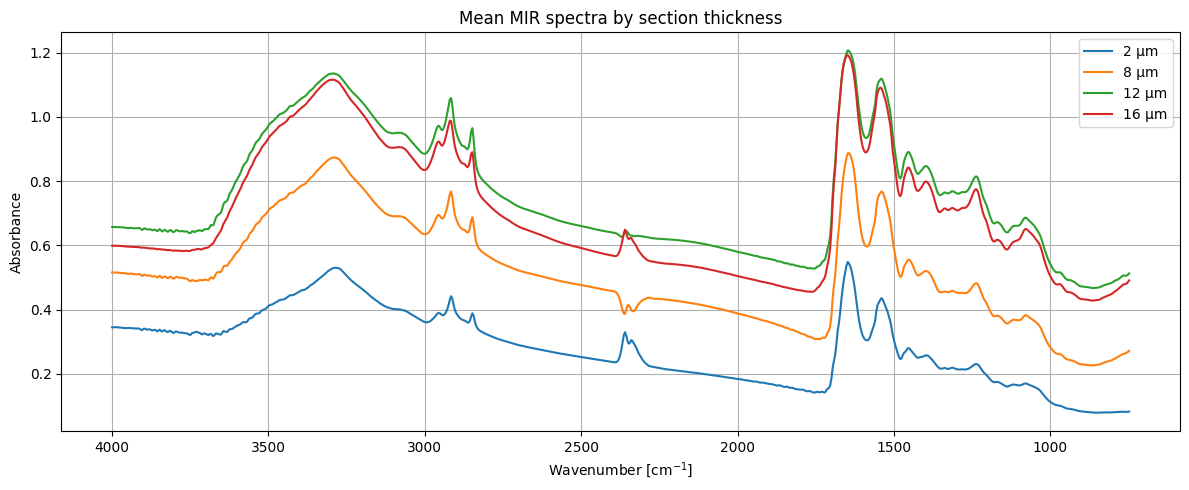

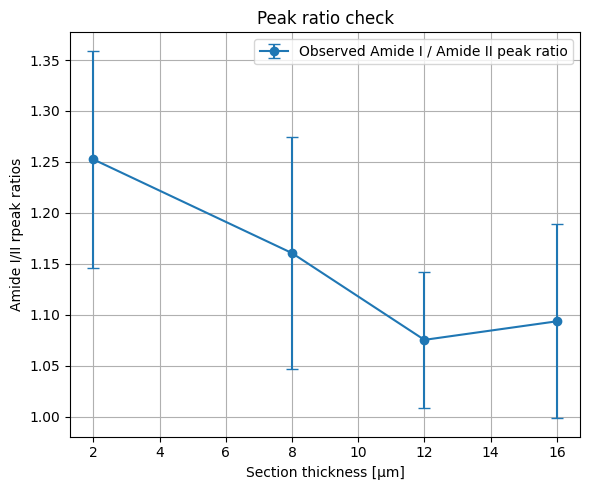

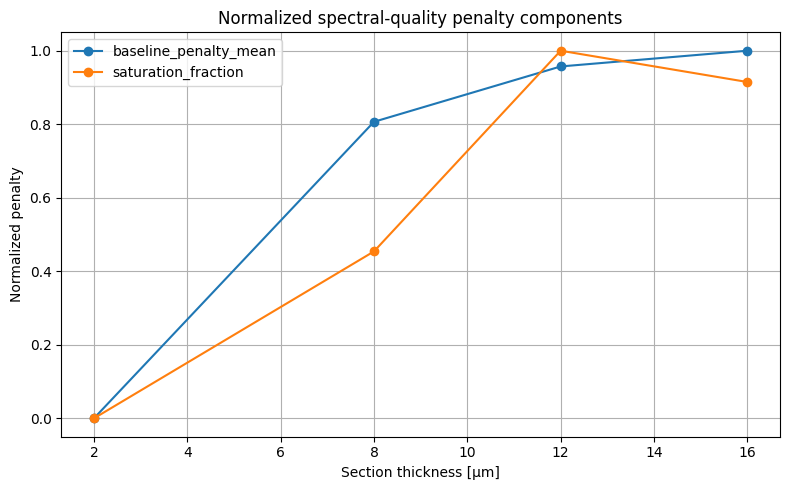

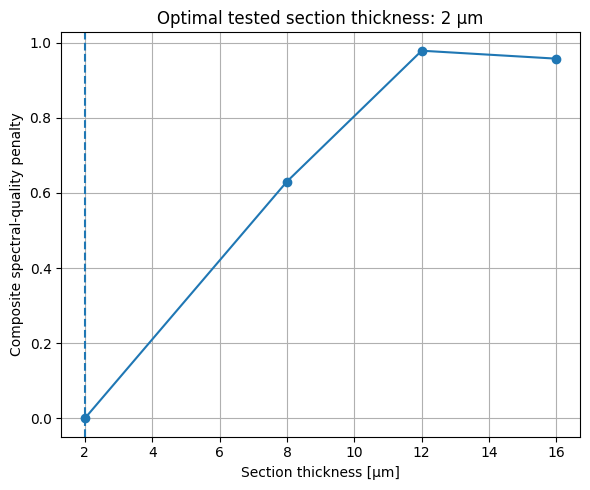

In [28]:
# Quality plots

plt.figure(figsize=(12, 5))
mean_spectra_by_thickness = {}
for t, group in df.groupby("thickness"):
    mean_spectrum = group[spectral_cols_sorted].mean(axis=0).to_numpy(dtype=float)
    mean_spectra_by_thickness[t] = mean_spectrum
for t in sorted(mean_spectra_by_thickness):
    plt.plot(
        wn_sorted,
        mean_spectra_by_thickness[t],
        label=f"{t} µm"
    )
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber [cm$^{-1}$]")
plt.ylabel("Absorbance")
plt.title("Mean MIR spectra by section thickness")
plt.legend()
plt.grid()
#plt.xlim(1700, 1200)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))

plt.errorbar(
    summary["thickness"],
    summary["amide_I_II_ratio_mean"],
    yerr=summary["amide_I_II_ratio_std"],
    marker="o",
    capsize=4,
    label="Observed Amide I / Amide II peak ratio"
)


plt.xlabel("Section thickness [µm]")
plt.ylabel("Amide I/II rpeak ratios")
plt.title("Peak ratio check")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

for col in penalty_cols:
    plt.plot(
        summary["thickness"],
        summary[col + "_norm"],
        marker="o",
        label=col
    )

plt.xlabel("Section thickness [µm]")
plt.ylabel("Normalized penalty")
plt.title("Normalized spectral-quality penalty components")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))

plt.plot(
    summary["thickness"],
    summary["quality_penalty"],
    marker="o"
)

best_t = summary.loc[summary["quality_penalty"].idxmin(), "thickness"]

plt.axvline(best_t, linestyle="--")
plt.xlabel("Section thickness [µm]")
plt.ylabel("Composite spectral-quality penalty")
plt.title(f"Optimal tested section thickness: {best_t} µm")
plt.grid()
plt.tight_layout()
plt.show()

## Where are the saturated spectra?

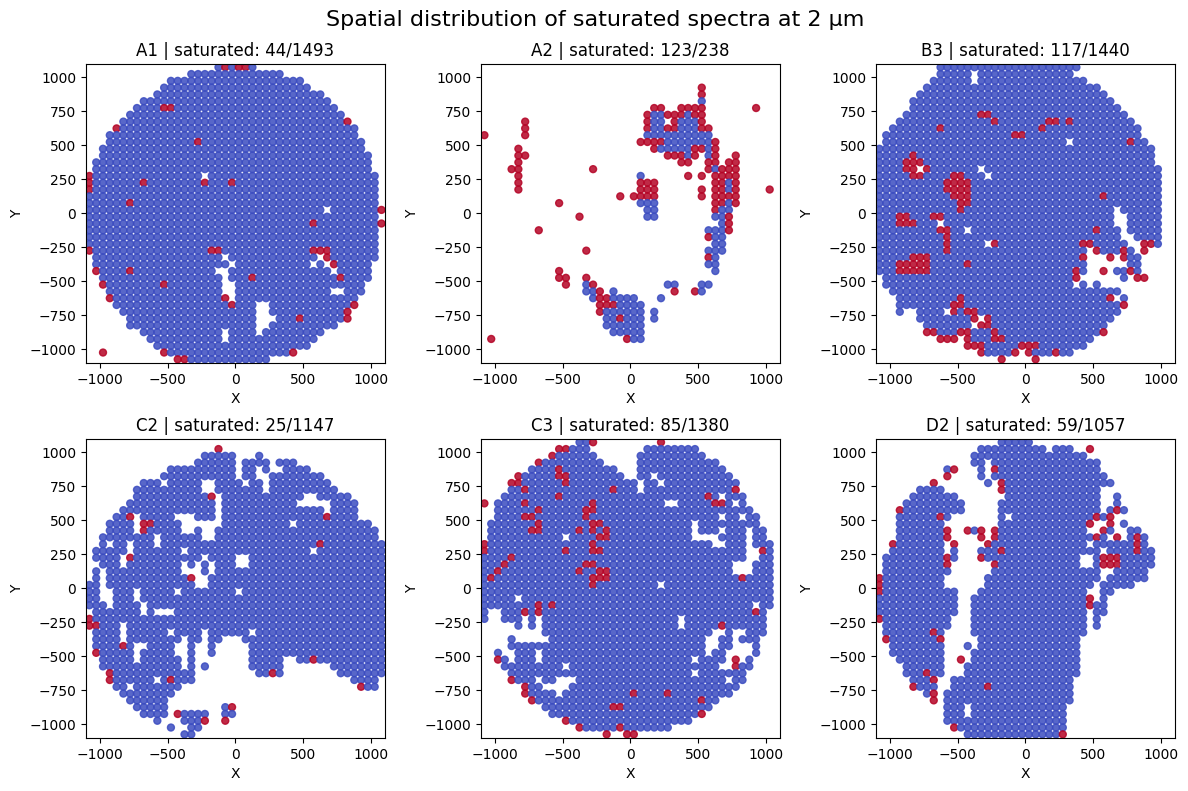

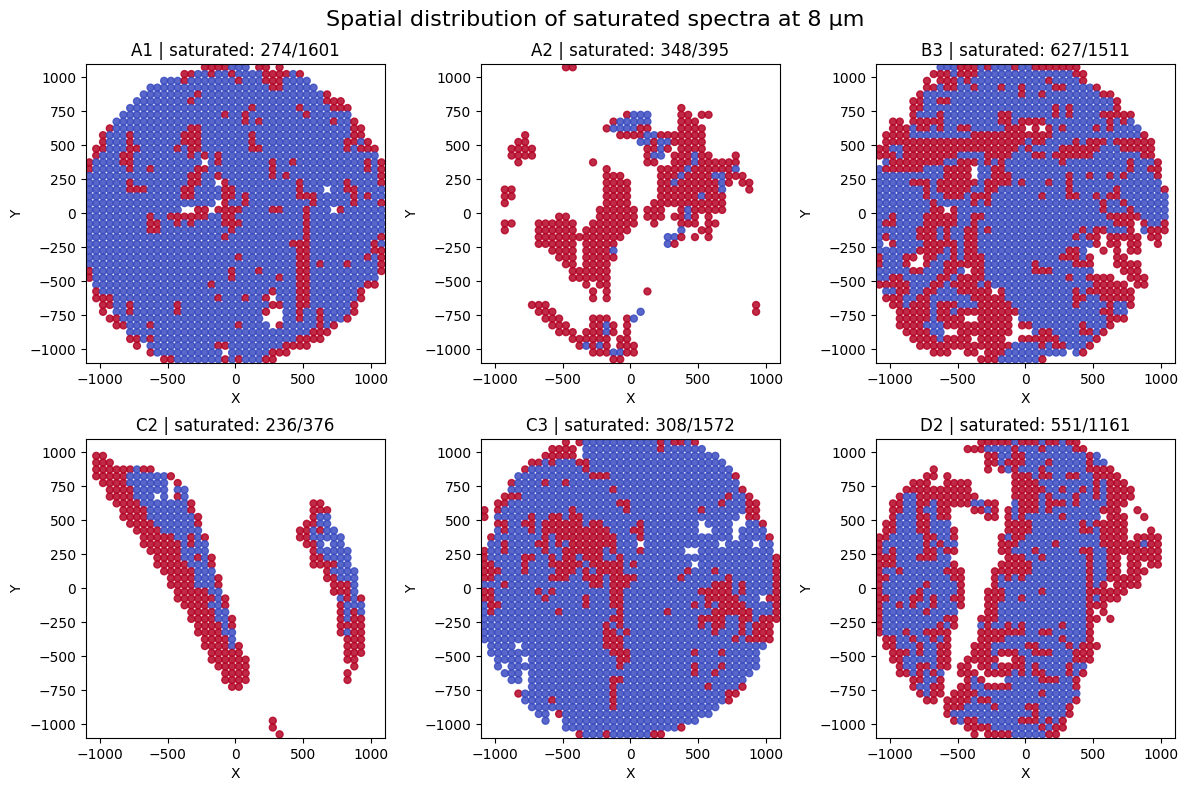

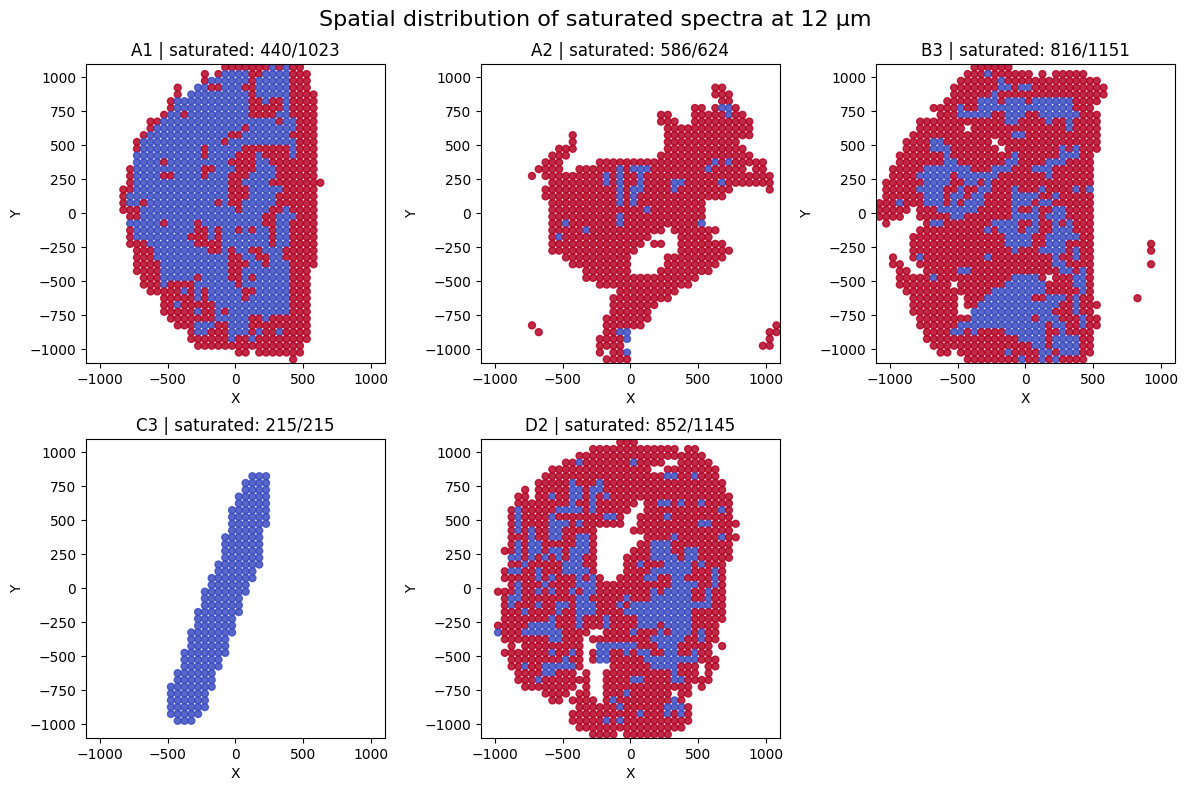

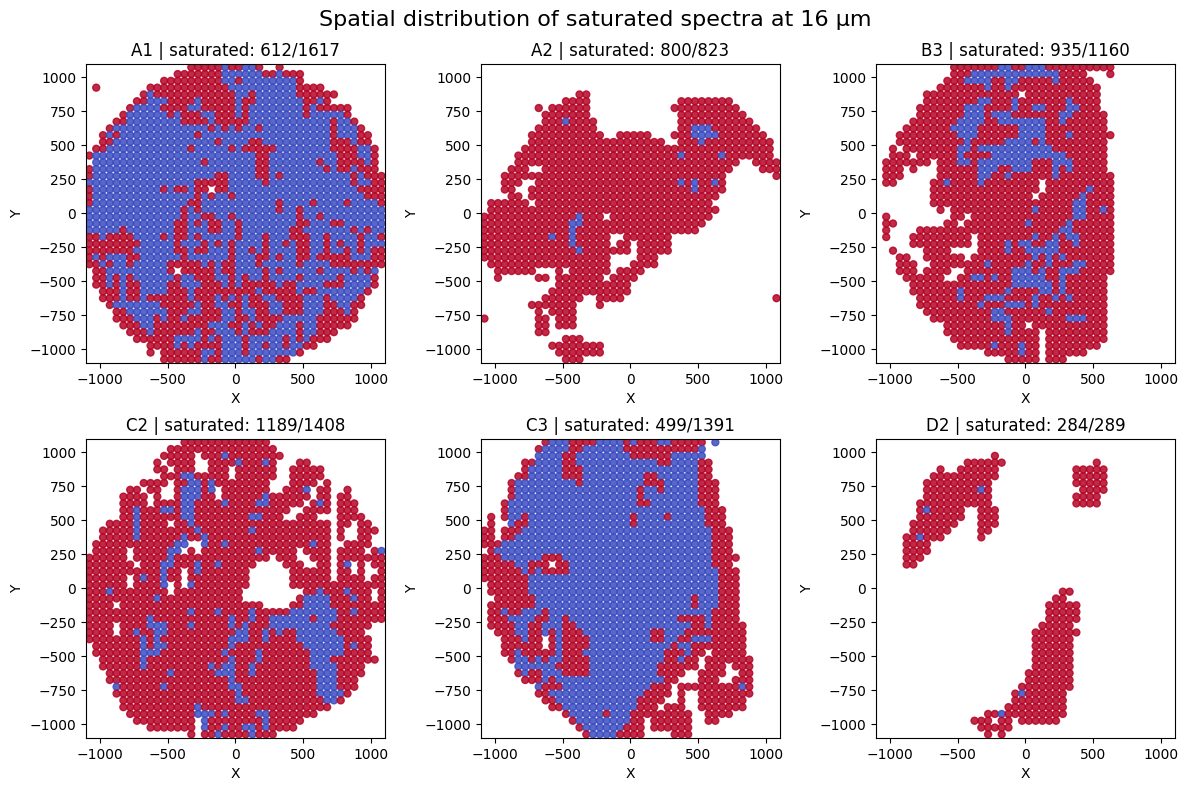

In [29]:
for i in np.sort(metrics["thickness"].unique()):
    m2 = metrics.loc[metrics["thickness"] == i].copy()
    sat_col = "is_saturated"
    cores = sorted(m2["labels"].unique())
    n_cores = len(cores)

    ncols = 3
    nrows = int(np.ceil(n_cores / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 4 * nrows),
        squeeze=False
    )

    for ax, core in zip(axes.ravel(), cores):
        core_df = m2.loc[m2["labels"] == core]
        ax.scatter(
            core_df["X"],
            core_df["Y"],
            c=core_df[sat_col].astype(int),
            cmap="coolwarm",
            s=25,
            alpha=0.85
        )

        n_sat = core_df[sat_col].sum()
        n_total = len(core_df)
        ax.set_title(f"{core} | saturated: {n_sat}/{n_total}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_aspect("equal")
        ax.set_xlim(-1100, 1100)
        ax.set_ylim(-1100, 1100)

    for ax in axes.ravel()[len(cores):]:
        ax.axis("off")

    fig.suptitle(f"Spatial distribution of saturated spectra at {i} µm", fontsize=16)
    plt.tight_layout()
    plt.show()